In [1]:
%%capture --no-stderr
%pip install -U langchain_ollama langgraph trustcall langchain_core

In [2]:
import os, getpass

def _set_env(var: str):
    # Check if the variable is set in the OS environment
    env_value = os.environ.get(var)
    if not env_value:
        # If not set, prompt the user for input
        env_value = getpass.getpass(f"{var}: ")
    
    # Set the environment variable for the current process
    os.environ[var] = env_value

_set_env("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"

In [3]:
from pydantic import BaseModel, Field

class Memory(BaseModel):
    memory: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

class MemoryCollection(BaseModel):
    memories: list[Memory] = Field(description="A list of memories about the user.")

In [4]:
from langchain_core.messages import HumanMessage
from langchain_ollama import ChatOllama

# Initialize the model
model = ChatOllama(model="llama3.1", temperature=0, num_ctx = 24576, num_predict = -1)

# Bind schema to model
model_with_structure = model.with_structured_output(MemoryCollection)

# Invoke the model to produce structured output that matches the schema
memory_collection = model_with_structure.invoke([HumanMessage("My name is Lance. I like to bike and swim.")])
memory_collection.memories

[Memory(memory='Lance likes to bike'), Memory(memory='Lance likes to swim')]

In [5]:
memory_collection.memories[0].model_dump()

{'memory': 'Lance likes to bike'}

In [6]:
import uuid
from langgraph.store.memory import InMemoryStore

# Initialize the in-memory store
in_memory_store = InMemoryStore()

# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memories")

# Save a memory to namespace as key and value
key = str(uuid.uuid4())
value = memory_collection.memories[0].model_dump()
in_memory_store.put(namespace_for_memory, key, value)

key = str(uuid.uuid4())
value = memory_collection.memories[1].model_dump()
in_memory_store.put(namespace_for_memory, key, value)

In [7]:
# Search 
for m in in_memory_store.search(namespace_for_memory):
    print(m.dict())

{'value': {'memory': 'Lance likes to bike'}, 'key': '9f595dd1-1314-4feb-a2e1-2f56d14ad3eb', 'namespace': ['1', 'memories'], 'created_at': '2024-12-20T11:39:08.903846+00:00', 'updated_at': '2024-12-20T11:39:08.903848+00:00', 'score': None}
{'value': {'memory': 'Lance likes to swim'}, 'key': '6c3fd3cd-3884-4a5e-bfc6-d3d605ee7c4a', 'namespace': ['1', 'memories'], 'created_at': '2024-12-20T11:39:08.903898+00:00', 'updated_at': '2024-12-20T11:39:08.903899+00:00', 'score': None}


In [8]:
from trustcall import create_extractor

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,
)

In [9]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# Instruction
instruction = """Extract memories from the following conversation:"""

# Conversation
conversation = [HumanMessage(content="Hi, I'm Lance."), 
                AIMessage(content="Nice to meet you, Lance."), 
                HumanMessage(content="This morning I had a nice bike ride in San Francisco.")]

# Invoke the extractor
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=instruction)] + conversation})

In [10]:
# Messages contain the tool calls
for m in result["messages"]:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  Memory (cb9e0079-2c9b-42ee-b133-86b2157a1f01)
 Call ID: cb9e0079-2c9b-42ee-b133-86b2157a1f01
  Args:
    memory: This morning I had a nice bike ride in San Francisco.


In [11]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

memory='This morning I had a nice bike ride in San Francisco.'


In [12]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

{'id': 'cb9e0079-2c9b-42ee-b133-86b2157a1f01'}


In [13]:
# Update the conversation
updated_conversation = [AIMessage(content="That's great, did you do after?"), 
                        HumanMessage(content="I went to Tartine and ate a croissant."),                        
                        AIMessage(content="What else is on your mind?"),
                        HumanMessage(content="I was thinking about my Japan, and going back this winter!"),]

# Update the instruction
system_msg = """Update existing memories and create new ones based on the following conversation:"""

# We'll save existing memories, giving them an ID, key (tool name), and value
tool_name = "Memory"
existing_memories = [(str(i), tool_name, memory.model_dump()) for i, memory in enumerate(result["responses"])] if result["responses"] else None
existing_memories

[('0',
  'Memory',
  {'memory': 'This morning I had a nice bike ride in San Francisco.'})]

In [14]:
# Invoke the extractor with our updated conversation and existing memories
result = trustcall_extractor.invoke({"messages": updated_conversation, 
                                     "existing": existing_memories})

In [15]:
# Messages from the model indicate two tool calls were made
print(result)
for m in result["messages"]:
    m.pretty_print()

{'messages': [AIMessage(content='To answer the question, we need to call the "PatchDoc" function with the following arguments:\n\n{"name": "PatchDoc", "parameters": {"json_doc_id": "0", "planned_edits": "I was thinking about my Japan, and going back this winter!", "patches": [{"op": "replace", "path": "/memory", "value": "I was thinking about my Japan, and going back this winter!"}]}\n\nThis function call will update the existing schema instance with the new memory content.', additional_kwargs={'updated_docs': {}}, response_metadata={}, id='155ff188-2043-4884-b9b8-dc3306953897')], 'responses': [], 'response_metadata': [], 'attempts': 4}
================================== Ai Message ==================================

To answer the question, we need to call the "PatchDoc" function with the following arguments:

{"name": "PatchDoc", "parameters": {"json_doc_id": "0", "planned_edits": "I was thinking about my Japan, and going back this winter!", "patches": [{"op": "replace", "path": "/mem

In [16]:
# Responses contain the memories that adhere to the schema
for m in result["responses"]: 
    print(m)

In [17]:
# Metadata contains the tool call  
for m in result["response_metadata"]: 
    print(m)

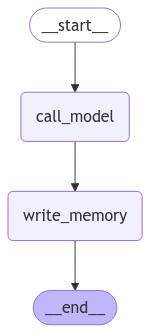

In [18]:
from IPython.display import Image, display

import uuid

from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.memory import InMemoryStore
from langchain_core.messages import merge_message_runs
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.base import BaseStore

# Initialize the model
model = ChatOllama(model="llama3.1", temperature=0, num_ctx = 24576, num_predict = -1)

# Memory schema
class Memory(BaseModel):
    content: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

# Create the Trustcall extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    # This allows the extractor to insert new memories
    enable_inserts=True,
)

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """You are a helpful chatbot. You are designed to be a companion to a user. 

You have a long term memory which keeps track of information you learn about the user over time.

Current Memory (may include updated memories from this conversation): 

{memory}"""

# Trustcall instruction
TRUSTCALL_INSTRUCTION = """Reflect on following interaction. 

Use the provided tools (Memory) to retain any necessary memories about the user. 

Use parallel tool calling to handle updates and insertions simultaneously:"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memories from the store and use them to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memories", user_id)
    memories = store.search(namespace)

    # Format the memories for the system prompt
    info = "\n".join(f"- {mem.value['content']}" for mem in memories)
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=info)

    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"] + [HumanMessage("")])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and update the memory collection."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Define the namespace for the memories
    namespace = ("memories", user_id)

    # Retrieve the most recent memories for context
    existing_items = store.search(namespace)

    # Format the existing memories for the Trustcall extractor
    tool_name = "Memory"
    existing_memories = ([(existing_item.key, tool_name, existing_item.value)
                          for existing_item in existing_items]
                          if existing_items
                          else None
                        )
    
    # Merge the chat history and the instruction
    updated_messages=list(merge_message_runs(messages=[SystemMessage(content=TRUSTCALL_INSTRUCTION)] + state["messages"] + [HumanMessage("")]))

    # Invoke the extractor
    result = trustcall_extractor.invoke({"messages": updated_messages, 
                                        "existing": existing_memories})

    # Save the memories from Trustcall to the store
    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace,
                  rmeta.get("json_doc_id", str(uuid.uuid4())),
                  r.model_dump(mode="json"),
            )

# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [19]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi, my name is Lance")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Nice to meet you, Lance! I'm glad we're starting our conversation together. I'll make sure to remember your name for future chats.

I don't have any specific information about you yet, so let's start fresh. How's your day going so far? Is there anything on your mind that you'd like to talk about or ask me about?


In [20]:
# User input 
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

San Francisco is a great city for biking! I've learned that you enjoy exploring the city on two wheels. That's awesome!

I'll make sure to keep this in mind as we chat, so if you need recommendations or advice on bike routes or trails in SF, I'll be happy to help.

By the way, do you have a favorite spot or route that you like to ride?


In [21]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memories", user_id)
memories = across_thread_memory.search(namespace)
for m in memories:
    print(m.dict())

In [22]:
# User input 
input_messages = [HumanMessage(content="I also enjoy going to bakeries")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I also enjoy going to bakeries
================================== Ai Message ==================================

Bakeries are a great addition to your interests! I've updated my memory to note that you not only enjoy biking around San Francisco but also appreciate good baked goods.

If you're willing to share, what's your favorite type of pastry or treat from the bakeries you visit? Are you more of a classic croissant fan or do you have a sweet tooth for something like a chocolate chip cookie?

(Also, I'm curious - are there any specific neighborhoods in San Francisco that you tend to visit for biking and bakery-hopping?)


In [23]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="What bakeries do you recommend for me?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

What bakeries do you recommend for me?
================================== Ai Message ==================================

I'm glad I can help with that! Based on our previous conversations, I know how much you enjoy visiting bakeries.

One of my top recommendations is Bi-Rite Bakery in the Mission District. They're known for their delicious sourdough bread and creative pastries. Another great option is Boudin Bakery, which has been a San Francisco institution since 1849! They offer a wide variety of freshly baked breads, including their famous Sourdough Boule.

If you're looking for something a bit more unique, I'd suggest checking out Foreign Cinema's bakery in the Mission District. They offer a range of delicious pastries and sandwiches made with fresh, locally-sourced ingredients.

Lastly, if you're willing to venture a bit further north, I highly recommend Acme Bread Company in Berkeley. They've been f